# Лабораторна робота №4 “Класифікація”
## Мета
Ознайомитися з основами класифікації при інтелектуальному аналізі даних на прикладі реального історичного набору даних Titanic.
Навчитись будувати класифікатор на основі дерев рішень (Decision Tree), виконувати попередню обробку даних, навчати модель, оцінювати якість класифікації за допомогою стандартних метрик та інтерпретувати отримані результати.

### Завантаження та попередня обробка даних
1. Викачати датасет Titanic із Kaggle.
2. Завантажити файл train.csv у DataFrame.
3. Вивести загальну інформацію про дані, перевірити наявність пропущених значень.
4. Заповнити пропущені значення.
5. Перетворити категоріальні ознаки у числовий формат.

### Поділ даних на навчальну та тестову вибірки
1. Виконати поділ даних на train/test.
2. Вивести розміри навчальної та тестової вибірок.

### Побудова класифікатора на основі дерев рішень
1. Навчити модель дерева рішень на навчальних даних.
2. Отримати класифікацію для тестової вибірки.
3. Проаналізувати глибину дерева та кількість вузлів.

### Оцінювання якості класифікації
1. Обчислити основні метрики класифікації:
- Accuracy;
- Precision;
- Recall;
- F1-score.
2. Побудувати confusion matrix.
3. Вивести детальний звіт класифікації (classification_report).
4. Проаналізувати баланс класів та пояснити, які метрики є більш інформативними для цього завдання.

### Інтерпретація моделі
1. Вивести важливість ознак (feature importance), отриману з дерева рішень.
2. Проаналізувати, які характеристики пасажирів найбільше впливають на ймовірність виживання.
3. Візуалізувати дерево рішень.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
train = pd.read_csv("train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test = pd.read_csv("test.csv")
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
print("Розмірність таблиці:")
print(train.shape)
print("\nІнформація про колонки:")
print(train.info())

Розмірність таблиці:
(891, 12)

Інформація про колонки:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [5]:
print("Розмірність таблиці:")
print(test.shape)
print("\nІнформація про колонки:")
print(test.info())

Розмірність таблиці:
(418, 11)

Інформація про колонки:
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB
None


In [6]:
train["Sex"] = train["Sex"].map({
    "male": 1,
    "female": 0
})
num_train = train.select_dtypes(include=np.number).drop(columns = "PassengerId")
train["Age"] = train["Age"].fillna(train["Age"].mean())

print(num_train.shape)
num_train.head()

(891, 7)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,1,22.0,1,0,7.2500
1,1,1,0,38.0,1,0,71.2833
2,1,3,0,26.0,0,0,7.9250
3,1,1,0,35.0,1,0,53.1000
4,0,3,1,35.0,0,0,8.0500


In [7]:
test["Sex"] = test["Sex"].map({
    "male": 1,
    "female": 0
})
num_test = test.select_dtypes(include=np.number).drop(columns = "PassengerId")
test["Age"] = test["Age"].fillna(test["Age"].mean())
print(num_test.shape)
num_test.head()

(418, 6)


,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,34.5,0,0,7.8292
1,3,0,47.0,1,0,7.0000
2,2,1,62.0,0,0,9.6875
3,3,1,27.0,0,0,8.6625
4,3,0,22.0,1,1,12.2875


In [8]:
X_train = num_train.drop(columns = "Survived")
y_train = num_train["Survived"]
X_test = num_test

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_val = pd.read_csv("gender_submission.csv")
y_val = y_val.drop(columns = "PassengerId")

print("Глибина дерева:", model.get_depth())
print("Кількість вузлів:", model.tree_.node_count)

Глибина дерева: 22
Кількість вузлів: 403


In [9]:
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1-score:", f1_score(y_val, y_pred))

Accuracy: 0.7894736842105263
Precision: 0.7077922077922078
Recall: 0.7171052631578947
F1-score: 0.7124183006535948


In [16]:
cm = confusion_matrix(y_val, y_pred)
print(cm)
print(classification_report(y_val, y_pred))

[[221  45]
 [ 43 109]]
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       266
           1       0.71      0.72      0.71       152

    accuracy                           0.79       418
   macro avg       0.77      0.77      0.77       418
weighted avg       0.79      0.79      0.79       418



In [17]:
print(train["Survived"].value_counts(normalize=True))

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [19]:
importances = model.feature_importances_
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

  Feature  Importance
1     Sex    0.309335
5    Fare    0.269653
2     Age    0.211544
0  Pclass    0.113778
3   SibSp    0.060026
4   Parch    0.035663


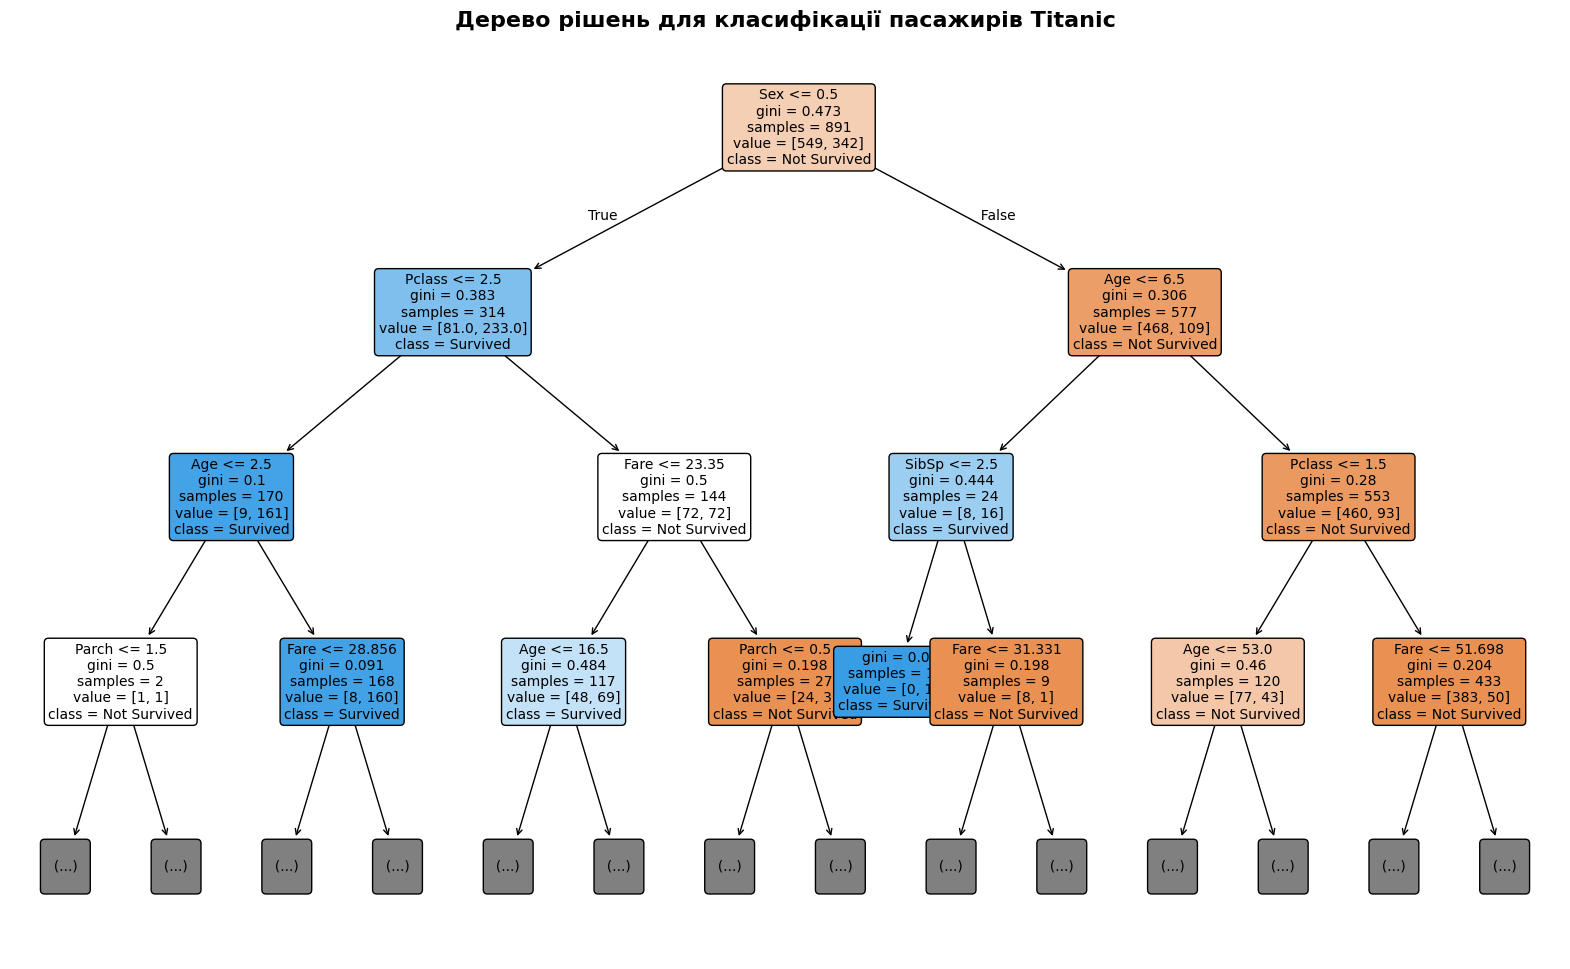

In [26]:
plt.figure(figsize=(20, 12))
plot_tree(model, 
          feature_names=features,
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)
plt.title("Дерево рішень для класифікації пасажирів Titanic", fontsize=16, fontweight='bold')
plt.show()

# Висновок
У ході лабораторної роботи було побудовано дерево рішень для прогнозування виживання на «Титаніку», яке продемонструвало точність близько 79%. Найбільш значущими ознаками виявилися стать (0.309) та вартість квитка (0.269). Хоча модель показала гарні результати метрик Precision та Recall, велика глибина дерева (22) свідчить про перенавчання.